In [ ]:
%%writefile final.cu

#include <iostream>             // cout для вывода в консоль
#include <cuda_runtime.h>         // CUDA runtime API
#include <vector>              // std::vector для массивов на CPU
#include <cstdlib>               // rand(), srand() для генерации
#include <chrono>                 // chrono для замера времени на CPU
#include <omp.h>                // OpenMP для распараллеливания на CPU
#include <climits>                 // INT_MIN для минимального int
using namespace std;         // чтобы не писать std:: каждый раз


// ЧАСТЬ 1. Общая инфраструктура проекта

static void cuda_ok(cudaError_t err, const char* msg) {           // функция проверяет код ошибки CUDA
    if (err != cudaSuccess) {                                // если вызов CUDA завершился ошибкой
        cout << "ошибка cuda (" << msg << "): "            // печатаем контекст ошибки (что делали)
             << cudaGetErrorString(err) << "\n";             // печатаем текст ошибки CUDA
        exit(1);                                          // аварийно завершаем программу
    }
}


// ЧАСТЬ 2. Последовательная реализация

static long long cpu_sum_seq(const int* a, int n) {           // последовательная сумма массива
    long long s = 0;                                     // это аккумулятор суммы, чтобы не переполнить int
    for (int i = 0; i < n; i++) s += a[i];                  // проходим по всем элементам и суммируем
    return s;                                       // возвращаем итоговую сумму
}

static int cpu_max_seq(const int* a, int n) {            // последовательный максимум массива
    int m = INT_MIN;                                   // начинаем с минимального int
    for (int i = 0; i < n; i++)                     // проходим по всем элементам массива
        if (a[i] > m) m = a[i];               // обновляем максимум, если нашли больше
    return m;                                  // возвращаем найденный максимум
}


// ЧАСТЬ 3. Параллельная реализация на CPU с OpenMP

static long long cpu_sum_omp(const int* a, int n) {            // сумма на CPU с OpenMP
    long long s = 0;                                       // общий аккумулятор суммы
#pragma omp parallel for reduction(+:s)                      // делим цикл по потокам и делаем reduction суммы
    for (int i = 0; i < n; i++) s += a[i];                  // каждый поток добавляет свою часть элементов
    return s;                                       // возвращаем объединённую сумму
}

static int cpu_max_omp(const int* a, int n) {             // максимум на CPU с OpenMP
    int m = INT_MIN;                                        // общий максимум (начинаем с минимума)
#pragma omp parallel for reduction(max:m)                  // делим цикл по потокам и делаем reduction(max)
    for (int i = 0; i < n; i++)                         // параллельный проход по индексам
        if (a[i] > m) m = a[i];                            // каждый поток обновляет свой локальный максимум
    return m;                                             // возвращаем глобальный максимум после reduction
}


// ЧАСТЬ 4. Реализация редукции на GPU с использованием CUDA
// ЧАСТЬ 4.1. CUDA kernel: редукция суммы и максимума внутри блока

__global__ void reduce_sum_max_kernel(const int* a, int n,             // CUDA kernel, входной массив и его размер
                                      unsigned long long* block_sums,        // выход: сумма каждого блока
                                      int* block_max) {                    // выход: максимум каждого блока
    extern __shared__ unsigned char shmem[];                            // динамическая shared memory
    unsigned long long* sh_sum = (unsigned long long*)shmem;                   // первая часть shared: суммы (по потоку)
    int* sh_max = (int*)(sh_sum + blockDim.x);                               // вторая часть shared: максимумы (по потоку)
    int tid = threadIdx.x;                                         // индекс потока внутри блока
    int gid = blockIdx.x * blockDim.x + tid;                         // глобальный индекс элемента в массиве
    unsigned long long v_sum = 0ULL;                              // локальный вклад в сумму (по умолчанию 0)
    int v_max = INT_MIN;                                           // локальный вклад в максимум (по умолчанию минимум)
    if (gid < n) {                                    // проверяем, что индекс не выходит за массив
        int x = a[gid];                                 // читаем элемент из глобальной памяти
        v_sum = (unsigned long long)x;              // кладём элемент в сумму (как unsigned long long)
        v_max = x;                                    // кладём элемент в максимум
    }

    sh_sum[tid] = v_sum;              // записываем локальную сумму в shared memory
    sh_max[tid] = v_max;               // записываем локальный максимум в shared memory
    __syncthreads();                 // синхронизация: все потоки должны записать данные
    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {           // дерево редукции, здесь шаг уменьшаем в 2 раза
        if (tid < stride) {                                            // работают только потоки в первой половине
            sh_sum[tid] += sh_sum[tid + stride];                     // суммируем пару значений для суммы
            int other = sh_max[tid + stride];                         // берём второй кандидат для максимума
            if (other > sh_max[tid]) sh_max[tid] = other;               // выбираем больший максимум из пары
        }
        __syncthreads();                                           // синхронизация перед следующим шагом редукции
    }

    if (tid == 0) {                                        // только поток 0 в блоке пишет результат блока
        block_sums[blockIdx.x] = sh_sum[0];                   // записываем сумму блока в глобальную память
        block_max[blockIdx.x]  = sh_max[0];                // записываем максимум блока в глобальную память
    }
}

// ЧАСТЬ 4.2. Host-код CUDA: память, kernel, замеры времени

static void gpu_sum_max(const int* h, int n,                          // функция считает sum+max на GPU для массива на CPU
                        unsigned long long& sum_out,                // выходной параметр: итоговая сумма
                        int& max_out,                             // выходной параметр: итоговый максимум
                        float& gpu_kernel_ms_out,                  // выход: время только kernel (мс)
                        float& gpu_total_ms_out) {                    // выход: время H2D+kernel+D2H (мс)

    int* d_a = nullptr;                                                 // указатель на массив в памяти GPU
    cuda_ok(cudaMalloc(&d_a, (size_t)n * sizeof(int)), "malloc d_a");            // выделяем память на GPU под входной массив
    int threads = 256;                                                 // число потоков в одном блоке
    int blocks = (n + threads - 1) / threads;                        // число блоков: округление вверх

    unsigned long long* d_block_sums = nullptr;                             // массив частичных сумм блоков на GPU
    int* d_block_max = nullptr;                                               // массив частичных максимумов блоков на GPU
    cuda_ok(cudaMalloc(&d_block_sums, (size_t)blocks * sizeof(unsigned long long)),                  // выделяем память под суммы блоков
            "malloc d_block_sums");                                         // подпись для сообщения об ошибке
    cuda_ok(cudaMalloc(&d_block_max, (size_t)blocks * sizeof(int)),                // выделяем память под максимумы блоков
            "malloc d_block_max");                                             // подпись для сообщения об ошибке

    size_t sh_bytes = (size_t)threads * sizeof(unsigned long long)  // shared memory под сумму (по потоку)
                    + (size_t)threads * sizeof(int);                // shared memory под максимум (по потоку)

    cuda_ok(cudaMemcpy(d_a, h, (size_t)n * sizeof(int),                        // копируем входные данные на GPU
                       cudaMemcpyHostToDevice), "copy h2d warmup");                    // направление копирования H2D
    reduce_sum_max_kernel<<<blocks, threads, sh_bytes>>>(d_a, n,                            // запускаем kernel (прогревочный запуск)
                                                         d_block_sums, d_block_max);         // куда писать частичные результаты
    cuda_ok(cudaGetLastError(), "kernel warmup");                                     // проверяем, что kernel запустился без ошибок
    cuda_ok(cudaDeviceSynchronize(), "sync warmup");                                      // ждём завершения warm-up kernel

    cudaEvent_t k_start, k_stop, t_start, t_stop;                      // CUDA события для измерения времени
    cuda_ok(cudaEventCreate(&k_start), "create k_start");          // создаём событие начала kernel-таймера
    cuda_ok(cudaEventCreate(&k_stop),  "create k_stop");            // создаём событие конца kernel-таймера
    cuda_ok(cudaEventCreate(&t_start), "create t_start");             // создаём событие начала total-таймера
    cuda_ok(cudaEventCreate(&t_stop),  "create t_stop");           // создаём событие конца total-таймера

    cuda_ok(cudaEventRecord(t_start), "record total start");                  // старт total time (копирование+kernel+копирование)
    cuda_ok(cudaMemcpy(d_a, h, (size_t)n * sizeof(int),                       // копируем массив на GPU для реального замера
                       cudaMemcpyHostToDevice), "copy h2d");                     // направление H2D

    cuda_ok(cudaEventRecord(k_start), "record kernel start");                // старт замера времени kernel
    reduce_sum_max_kernel<<<blocks, threads, sh_bytes>>>(d_a, n,                // запускаем основной kernel
                                                         d_block_sums, d_block_max);          // массивы частичных результатов
    cuda_ok(cudaGetLastError(), "kernel launch");                                // проверяем ошибки запуска kernel
    cuda_ok(cudaEventRecord(k_stop), "record kernel stop");                           // ставим событие конца kernel
    cuda_ok(cudaEventSynchronize(k_stop), "sync kernel stop");                            // ждём, пока kernel точно завершится
    cuda_ok(cudaEventElapsedTime(&gpu_kernel_ms_out, k_start, k_stop),               // считаем время kernel в миллисекундах
            "elapsed kernel");                                                              // подпись для проверки ошибок

    vector<unsigned long long> h_block_sums(blocks);            // буфер на CPU для сумм блоков (после D2H)
    vector<int> h_block_max(blocks);                           // буфер на CPU для максимумов блоков (после D2H)

    cuda_ok(cudaMemcpy(h_block_sums.data(), d_block_sums,                       // копируем суммы блоков с GPU на CPU
                       (size_t)blocks * sizeof(unsigned long long),
                       cudaMemcpyDeviceToHost), "copy sums d2h");                   // направление D2H
    cuda_ok(cudaMemcpy(h_block_max.data(), d_block_max,                            // копируем максимумы блоков с GPU на CPU
                       (size_t)blocks * sizeof(int),
                       cudaMemcpyDeviceToHost), "copy max d2h");                 // направление D2H

    cuda_ok(cudaEventRecord(t_stop), "record total stop");                          // ставим событие окончания total time
    cuda_ok(cudaEventSynchronize(t_stop), "sync total stop");                      // ждём завершения всех операций до t_stop
    cuda_ok(cudaEventElapsedTime(&gpu_total_ms_out, t_start, t_stop),                 // считаем total время (H2D+K+D2H)
            "elapsed total");                                                       // подпись для проверки ошибок

    unsigned long long s = 0ULL;                                // итоговая сумма (после объединения блоков)
    int m = INT_MIN;                                       // итоговый максимум (после объединения блоков)
    for (int i = 0; i < blocks; i++) {                       // проходим по всем блокам (их мало по сравнению с n)
        s += h_block_sums[i];                                 // складываем частичные суммы блоков
        if (h_block_max[i] > m) m = h_block_max[i];                 // берём максимум среди максимумов блоков
    }

    sum_out = s;                   // записываем итоговую сумму в выходной параметр
    max_out = m;                  // записываем итоговый максимум в выходной параметр

    cuda_ok(cudaEventDestroy(k_start), "destroy k_start");                 // удаляем событие начала kernel
    cuda_ok(cudaEventDestroy(k_stop),  "destroy k_stop");                // удаляем событие конца kernel
    cuda_ok(cudaEventDestroy(t_start), "destroy t_start");                // удаляем событие начала total
    cuda_ok(cudaEventDestroy(t_stop),  "destroy t_stop");                  // удаляем событие конца total

    cuda_ok(cudaFree(d_a), "free d_a");                                       // освобождаем память входного массива на GPU
    cuda_ok(cudaFree(d_block_sums), "free d_block_sums");                     // освобождаем память частичных сумм на GPU
    cuda_ok(cudaFree(d_block_max), "free d_block_max");                   // освобождаем память частичных максимумов на GPU
}


// ЧАСТЬ 5. Эксперимент, сравнение результатов и вывод

static void run_size(int n) {                                   // запускаем тест на одном размере массива
    vector<int> a(n);                                             // создаём массив на CPU из n элементов
    for (int i = 0; i < n; i++) a[i] = rand() % 1000;               // заполняем случайными числами

    auto s1 = chrono::high_resolution_clock::now();                    // старт таймера для sequential CPU
    long long sum_seq = cpu_sum_seq(a.data(), n);                         // считаем сумму последовательно
    int max_seq = cpu_max_seq(a.data(), n);                             // считаем максимум последовательно
    auto e1 = chrono::high_resolution_clock::now();                      // конец таймера sequential CPU
    double t_seq = chrono::duration<double, milli>(e1 - s1).count();         // переводим длительность в миллисекунды

    auto s2 = chrono::high_resolution_clock::now();                    // старт таймера для OpenMP CPU
    long long sum_omp = cpu_sum_omp(a.data(), n);                         // считаем сумму с OpenMP
    int max_omp = cpu_max_omp(a.data(), n);                             // считаем максимум с OpenMP
    auto e2 = chrono::high_resolution_clock::now();                   // конец таймера OpenMP CPU
    double t_omp = chrono::duration<double, milli>(e2 - s2).count();        // длительность OpenMP в миллисекундах

    unsigned long long sum_gpu = 0ULL;                    // здесь будет сумма с GPU
    int max_gpu = 0;                                     // здесь будет максимум с GPU
    float t_gpu_kernel = 0.0f;                           // время только kernel (мс)
    float t_gpu_total = 0.0f;                            // время H2D+kernel+D2H (мс)
    gpu_sum_max(a.data(), n, sum_gpu, max_gpu,          // запускаем GPU версию и получаем результаты
                t_gpu_kernel, t_gpu_total);               // получаем оба времени замера

    bool ok_sum = (sum_seq == (long long)sum_gpu)                       // проверяем: сумма GPU совпала с seq
               && (sum_omp == (long long)sum_gpu);                     // проверяем: сумма OpenMP тоже совпала
    bool ok_max = (max_seq == max_gpu)                                // проверяем: максимум GPU совпал с seq
               && (max_omp == max_gpu);                                 // проверяем: максимум OpenMP тоже совпал

    double speed_omp = (t_omp > 0.0 ? t_seq / t_omp : 0.0);                                     // ускорение OpenMP относительно seq
    double speed_gpu_kernel = (t_gpu_kernel > 0.0 ? t_seq / (double)t_gpu_kernel : 0.0);            // ускорение GPU kernel
    double speed_gpu_total  = (t_gpu_total  > 0.0 ? t_seq / (double)t_gpu_total  : 0.0);            // ускорение GPU total

    cout << "\n________________________________________________\n";           // разделительная линия для читаемости
    cout << "размер: " << n << "\n";                                     // вывод размера массива
    cout << "seq cpu:        " << t_seq << " мс\n";                  // вывод времени seq CPU
    cout << "omp cpu:        " << t_omp << " мс\n";                     // вывод времени OpenMP CPU
    cout << "gpu cuda kernel time:    " << t_gpu_kernel << " мс\n";               // вывод времени kernel (GPU)
    cout << "gpu cuda total: " << t_gpu_total << " мс\n";               // вывод полного GPU времени
    cout << "ускорение omp:          " << speed_omp << "\n";                  // вывод speedup OpenMP
    cout << "ускорение gpu kernel:   " << speed_gpu_kernel << "\n";             // вывод speedup GPU kernel
    cout << "ускорение gpu total:    " << speed_gpu_total << "\n";           // вывод speedup GPU total
    cout << "sum ok: " << (ok_sum ? "да" : "нет") << "\n";                // вывод результата проверки суммы
    cout << "max ok: " << (ok_max ? "да" : "нет") << "\n";               // вывод результата проверки максимума
    cout << "sum = " << sum_seq << "\n";                                        // вывод эталонной суммы (seq)
    cout << "max = " << max_seq << "\n";                                   // вывод эталонного максимума (seq)
}


int main() {
    srand(123);                  // фиксируем seed, чтобы результаты были повторяемыми

    cudaDeviceProp prop;                                                       // структура с характеристиками GPU
    cuda_ok(cudaGetDeviceProperties(&prop, 0), "get device properties");        // получаем свойства GPU устройства 0
    cout << "gpu: " << prop.name << "\n";                                       // печатаем название видеокарты

    run_size(100000);                      // тест для 100k элементов
    run_size(1000000);                       // тест для 1 млн элементов
    run_size(10000000);                     // тест для 10 млн элементов

    return 0;                                                       // возвращаем код успешного завершения
}

Writing final.cu


In [ ]:
%%bash
# компиляция и запуск в colab (cuda + openmp)
CC_DOT=$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -n1 | tr -d ' ')
CC=$(echo $CC_DOT | tr -d '.')

nvcc -O2 -Xcompiler -fopenmp -gencode arch=compute_${CC},code=sm_${CC} final.cu -o final
./final

gpu: Tesla T4

________________________________________________
размер: 100000
seq cpu:        0.125269 мс
omp cpu:        0.185081 мс
gpu cuda kernel time:    0.024 мс
gpu cuda total: 0.196704 мс
ускорение omp:          0.676833
ускорение gpu kernel:   5.21954
ускорение gpu total:    0.63684
sum ok: да
max ok: да
sum = 49706568
max = 999

________________________________________________
размер: 1000000
seq cpu:        1.30834 мс
omp cpu:        1.07407 мс
gpu cuda kernel time:    0.112928 мс
gpu cuda total: 1.00995 мс
ускорение omp:          1.21811
ускорение gpu kernel:   11.5856
ускорение gpu total:    1.29545
sum ok: да
max ok: да
sum = 498820231
max = 999

________________________________________________
размер: 10000000
seq cpu:        14.9661 мс
omp cpu:        11.2798 мс
gpu cuda kernel time:    1.01443 мс
gpu cuda total: 9.77946 мс
ускорение omp:          1.32681
ускорение gpu kernel:   14.7532
ускорение gpu total:    1.53036
sum ok: да
max ok: да
sum = 4994438803
max = 999


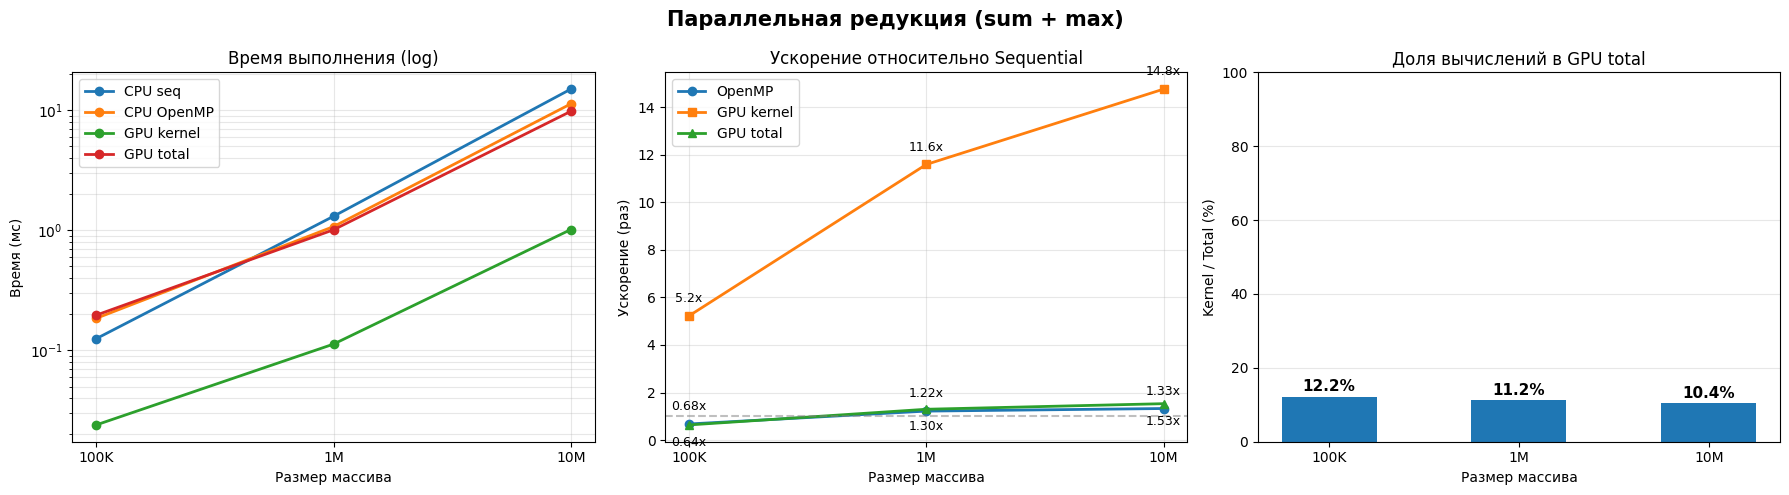

In [ ]:
import matplotlib.pyplot as plt  # подключаем matplotlib для графиков
import numpy as np  # numpy нужен для удобных массивов и позиций по оси X

# данные из вывода программы final.cu (время в миллисекундах)
n = [100000, 1000000, 10000000]  # три размера массива для тестов

seq       = [0.125269, 1.30834,  14.9661]   # sequential CPU, просто цикл
omp       = [0.185081, 1.07407,  11.2798]   # OpenMP CPU, параллельный цикл
gpu_kern  = [0.024,    0.112928, 1.01443]   # GPU kernel, чисто вычисления без копирования
gpu_total = [0.196704, 1.00995,  9.77946]   # GPU total, вместе с копированием H2D и D2H

# считаем во сколько раз каждый вариант быстрее sequential
spd_omp  = [seq[i] / omp[i] for i in range(3)]        # ускорение OpenMP
spd_kern = [seq[i] / gpu_kern[i] for i in range(3)]   # ускорение GPU kernel
spd_tot  = [seq[i] / gpu_total[i] for i in range(3)]  # ускорение GPU total

# какой процент от полного GPU времени занимает сам kernel
share = [gpu_kern[i] / gpu_total[i] * 100 for i in range(3)]  # остальное это копирование данных

x = np.arange(3)  # три позиции по оси X, одна на каждый размер
labels = ['100K', '1M', '10M']  # человекочитаемые подписи вместо чисел

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # создаём фигуру с тремя графиками в ряд
fig.suptitle('Параллельная редукция (sum + max)', fontsize=15, fontweight='bold')  # общий заголовок сверху

# 1) время выполнения, логарифмическая шкала
ax = axes[0]  # берём левый график
ax.plot(x, seq, 'o-', lw=2, label='CPU seq')  # рисуем линию sequential
ax.plot(x, omp, 'o-', lw=2, label='CPU OpenMP')  # рисуем линию openmp
ax.plot(x, gpu_kern, 'o-', lw=2, label='GPU kernel')  # рисуем линию gpu kernel
ax.plot(x, gpu_total, 'o-', lw=2, label='GPU total')  # рисуем линию gpu total
ax.set_yscale('log')  # лог шкала нужна потому что значения от 0.02 до 14 мс
ax.set_xticks(x)  # ставим метки в позициях 0 1 2
ax.set_xticklabels(labels)  # заменяем цифры на 100K 1M 10M
ax.set_xlabel('Размер массива')  # подпись оси X
ax.set_ylabel('Время (мс)')  # подпись оси Y
ax.set_title('Время выполнения (log)')  # заголовок этого графика
ax.grid(True, which='both', alpha=0.3)  # полупрозрачная сетка чтобы удобнее читать
ax.legend()  # показываем легенду с названиями линий

# 2) ускорение относительно sequential
ax = axes[1]  # берём средний график
ax.plot(x, spd_omp, 'o-', lw=2, label='OpenMP')  # линия ускорения openmp
ax.plot(x, spd_kern, 's-', lw=2, label='GPU kernel')  # линия ускорения gpu kernel
ax.plot(x, spd_tot, '^-', lw=2, label='GPU total')  # линия ускорения gpu total
ax.axhline(1, ls='--', color='gray', alpha=0.5)  # пунктир на уровне 1x, ниже значит медленнее seq
ax.set_xticks(x)  # метки по X
ax.set_xticklabels(labels)  # подписи 100K 1M 10M
ax.set_xlabel('Размер массива')  # подпись оси X
ax.set_ylabel('Ускорение (раз)')  # подпись оси Y
ax.set_title('Ускорение относительно Sequential')  # заголовок графика
ax.grid(alpha=0.3)  # лёгкая сетка
ax.legend()  # легенда
for i in range(3):  # подписываем конкретные значения прямо рядом с точками
    ax.annotate(f'{spd_omp[i]:.2f}x', (i, spd_omp[i]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)  # значение openmp сверху
    ax.annotate(f'{spd_kern[i]:.1f}x', (i, spd_kern[i]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)  # значение kernel сверху
    ax.annotate(f'{spd_tot[i]:.2f}x', (i, spd_tot[i]), textcoords='offset points', xytext=(0, -15), ha='center', fontsize=9)  # значение total снизу чтобы не налезало

# 3) доля kernel внутри GPU total
ax = axes[2]  # берём правый график
bars = ax.bar(labels, share, width=0.5)  # рисуем столбики с процентами
for bar, val in zip(bars, share):  # проходим по столбикам и подписываем значения сверху
    ax.text(bar.get_x() + bar.get_width() / 2,  # X по центру столбика
            bar.get_height() + 1.5,  # Y чуть выше верхушки
            f'{val:.1f}%',  # текст с процентом
            ha='center', fontsize=11, fontweight='bold')  # по центру жирным
ax.set_xlabel('Размер массива')  # подпись оси X
ax.set_ylabel('Kernel / Total (%)')  # подпись оси Y
ax.set_title('Доля вычислений в GPU total')  # заголовок графика
ax.set_ylim(0, 100)  # фиксируем от 0 до 100 процентов
ax.grid(axis='y', alpha=0.3)  # сетка только горизонтальная

plt.tight_layout()  # автоподгонка чтобы ничего не налезало друг на друга
plt.savefig('final_benchmark.png', dpi=150, bbox_inches='tight')  # сохраняем картинку в файл
plt.show()  # выводим на экран

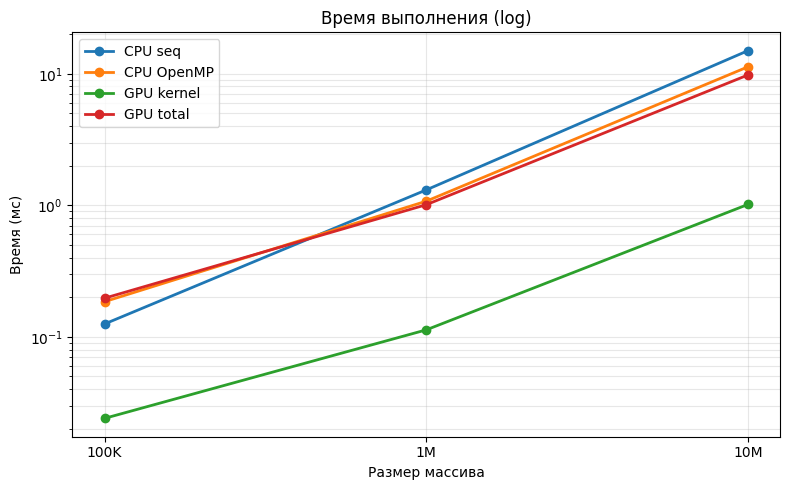

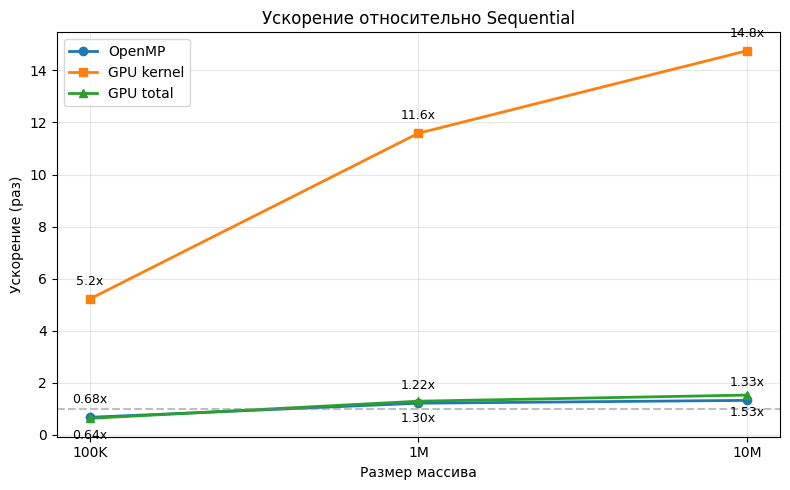

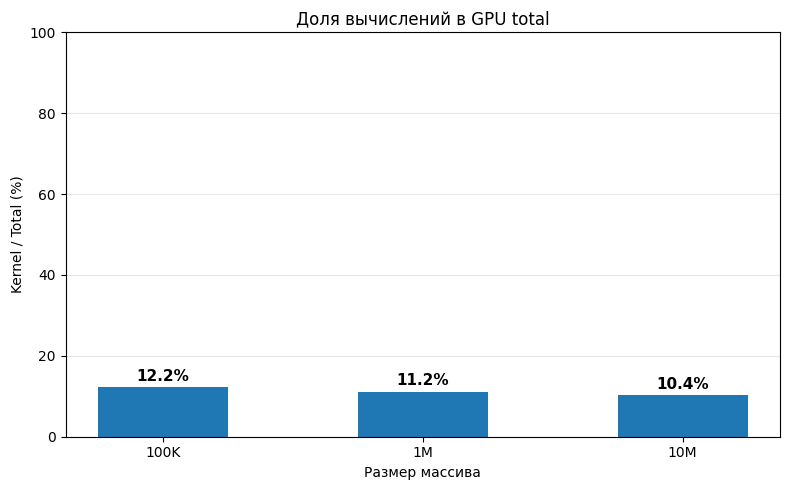

In [ ]:
import matplotlib.pyplot as plt  # подключаем matplotlib для графиков
import numpy as np  # numpy нужен для удобных массивов и позиций по оси X

# данные из вывода программы final.cu (время в миллисекундах)
n = [100000, 1000000, 10000000]  # три размера массива для тестов

seq       = [0.125269, 1.30834,  14.9661]   # sequential CPU, просто цикл
omp       = [0.185081, 1.07407,  11.2798]   # OpenMP CPU, параллельный цикл
gpu_kern  = [0.024,    0.112928, 1.01443]   # GPU kernel, чисто вычисления без копирования
gpu_total = [0.196704, 1.00995,  9.77946]   # GPU total, вместе с копированием H2D и D2H

# считаем во сколько раз каждый вариант быстрее sequential
spd_omp  = [seq[i] / omp[i] for i in range(3)]        # ускорение OpenMP
spd_kern = [seq[i] / gpu_kern[i] for i in range(3)]   # ускорение GPU kernel
spd_tot  = [seq[i] / gpu_total[i] for i in range(3)]  # ускорение GPU total

# какой процент от полного GPU времени занимает сам kernel
share = [gpu_kern[i] / gpu_total[i] * 100 for i in range(3)]  # остальное это копирование данных

x = np.arange(3)  # три позиции по оси X, одна на каждый размер
labels = ['100K', '1M', '10M']  # человекочитаемые подписи вместо чисел


# ============================================================
# ГРАФИК 1: время выполнения (лог шкала)
# ============================================================
plt.figure(figsize=(8, 5))  # отдельная фигура 8x5 дюймов
plt.plot(x, seq, 'o-', lw=2, label='CPU seq')  # линия sequential
plt.plot(x, omp, 'o-', lw=2, label='CPU OpenMP')  # линия openmp
plt.plot(x, gpu_kern, 'o-', lw=2, label='GPU kernel')  # линия gpu kernel
plt.plot(x, gpu_total, 'o-', lw=2, label='GPU total')  # линия gpu total
plt.yscale('log')  # лог шкала, значения от 0.02 до 14 мс
plt.xticks(x, labels)  # подписи 100K 1M 10M
plt.xlabel('Размер массива')  # подпись оси X
plt.ylabel('Время (мс)')  # подпись оси Y
plt.title('Время выполнения (log)')  # заголовок
plt.grid(True, which='both', alpha=0.3)  # полупрозрачная сетка
plt.legend()  # легенда
plt.tight_layout()  # чтобы ничего не обрезалось
plt.savefig('graph1_time.png', dpi=150, bbox_inches='tight')  # сохраняем
plt.show()  # показываем


# ============================================================
# ГРАФИК 2: ускорение относительно sequential
# ============================================================
plt.figure(figsize=(8, 5))  # отдельная фигура
plt.plot(x, spd_omp, 'o-', lw=2, label='OpenMP')  # speedup openmp
plt.plot(x, spd_kern, 's-', lw=2, label='GPU kernel')  # speedup kernel
plt.plot(x, spd_tot, '^-', lw=2, label='GPU total')  # speedup total
plt.axhline(1, ls='--', color='gray', alpha=0.5)  # пунктир y=1, граница быстрее/медленнее
plt.xticks(x, labels)  # подписи по X
plt.xlabel('Размер массива')  # подпись оси X
plt.ylabel('Ускорение (раз)')  # подпись оси Y
plt.title('Ускорение относительно Sequential')  # заголовок
plt.grid(alpha=0.3)  # лёгкая сетка
plt.legend()  # легенда
for i in range(3):  # подписываем значения рядом с точками
    plt.annotate(f'{spd_omp[i]:.2f}x', (i, spd_omp[i]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)  # openmp сверху
    plt.annotate(f'{spd_kern[i]:.1f}x', (i, spd_kern[i]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)  # kernel сверху
    plt.annotate(f'{spd_tot[i]:.2f}x', (i, spd_tot[i]), textcoords='offset points', xytext=(0, -15), ha='center', fontsize=9)  # total снизу чтобы не налезало
plt.tight_layout()  # подгонка отступов
plt.savefig('graph2_speedup.png', dpi=150, bbox_inches='tight')  # сохраняем
plt.show()  # показываем


# ============================================================
# ГРАФИК 3: доля kernel внутри GPU total
# ============================================================
plt.figure(figsize=(8, 5))  # отдельная фигура
bars = plt.bar(labels, share, width=0.5)  # столбики с процентами
for bar, val in zip(bars, share):  # подписываем значения над столбиками
    plt.text(bar.get_x() + bar.get_width() / 2,  # X по центру столбика
             bar.get_height() + 1.5,  # Y чуть выше верхушки
             f'{val:.1f}%',  # текст с процентом
             ha='center', fontsize=11, fontweight='bold')  # жирным по центру
plt.xlabel('Размер массива')  # подпись оси X
plt.ylabel('Kernel / Total (%)')  # подпись оси Y
plt.title('Доля вычислений в GPU total')  # заголовок
plt.ylim(0, 100)  # от 0 до 100 процентов
plt.grid(axis='y', alpha=0.3)  # горизонтальная сетка
plt.tight_layout()  # подгонка
plt.savefig('graph3_kernel_share.png', dpi=150, bbox_inches='tight')  # сохраняем
plt.show()  # показываем